# MNIST parameter sweeps

Explore how `IteratedMSTEmbedding` changes on real MNIST. The notebook downloads the full 70,000-image `mnist_784` dataset from OpenML once, caches it, and uses a stratified subsample. `SAMPLE_SIZE=2000` is the default and can be changed in the data cell below. Pixel intensities are scaled to `[0, 1]`, then each feature is standardized to zero mean and unit variance.

The default 500 epochs and larger MST counts can take a few minutes. For a quick iteration, lower `N_EPOCHS` or shorten `VALUES`; restore 500 epochs for a final comparison.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

from pathlib import Path
import sys

# Add the notebook helper module when running from the repository or notebooks/.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "notebooks" / "digits_sweep.py").is_file()),
    None,
)
if repo_root is not None:
    sys.path.insert(0, str(repo_root / "notebooks"))

from digits_sweep import load_mnist_data, run_sweep

## Load a stratified MNIST subsample

In [2]:
SAMPLE_SIZE = 2000  # Set to None to use all 70,000 rows.
DATA_RANDOM_STATE = 42
X, labels = load_mnist_data(
    sample_size=SAMPLE_SIZE,
    random_state=DATA_RANDOM_STATE,
)
print(f"Samples: {X.shape[0]}, features: {X.shape[1]}")

Samples: 2000, features: 784


## Choose a sweep

Set `PARAMETER` to any estimator parameter, such as `"n_msts"`, `"lambda_rep"`, or `"learning_rate"`, and set `VALUES` to the candidates. `BASE_PARAMS` supplies the remaining estimator settings.

Set `N_JOBS=1` for sequential runs or a larger value to fit several candidates at once. Each worker builds a dense pairwise distance matrix, so keep the worker count modest for larger datasets.

In [3]:
PARAMETER = "n_msts"
VALUES = [1, 2, 4, 6, 8, 10, 16, 32, 64]

BASE_PARAMS = {
    "n_epochs": 500,
    "batch_size": 4096,
    "learning_rate": 0.05,
    "negative_ratio": 4,
    "lambda_rep": 1.0,
    "random_state": 42,
    "epsilon": 1e-4,
    "device": "auto",
}
TRUSTWORTHINESS_NEIGHBORS = 10
N_JOBS = 4

Each panel colors samples by their digit label and reports 5-fold cross-validated 5-nearest-neighbor accuracy using the 2D coordinates. Trustworthiness summarizes how well local neighborhoods in the original standardized input features are preserved in 2D. Both scores are for comparison only and are not used to train the embedding. The accuracy is a transductive estimate: the embedding was fitted jointly on all unlabeled samples before the classifier folds were evaluated.

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Fitting n_msts=2 ...
Fitting n_msts=6 ...
Fitting n_msts=4 ...
Fitting n_msts=1 ...
Finished n_msts=1 in 2 sec on cpu
Finished n_msts=2 in 2 sec on cpu
Fitting n_msts=8 ...
Fitting n_msts=10 ...
Finished n_msts=4 in 3 sec on cpu
Fitting n_msts=16 ...
Finished n_msts=6 in 3 sec on cpu


[Parallel(n_jobs=4)]: Done   4 out of   9 | elapsed:    5.4s remaining:    6.7s


Fitting n_msts=32 ...
Finished n_msts=8 in 3 sec on cpu
Fitting n_msts=64 ...
Finished n_msts=10 in 3 sec on cpu


[Parallel(n_jobs=4)]: Done   6 out of   9 | elapsed:    7.8s remaining:    3.9s


Finished n_msts=16 in 4 sec on cpu
Finished n_msts=32 in 8 sec on cpu
Finished n_msts=64 in 14 sec on cpu


[Parallel(n_jobs=4)]: Done   9 out of   9 | elapsed:   21.4s finished


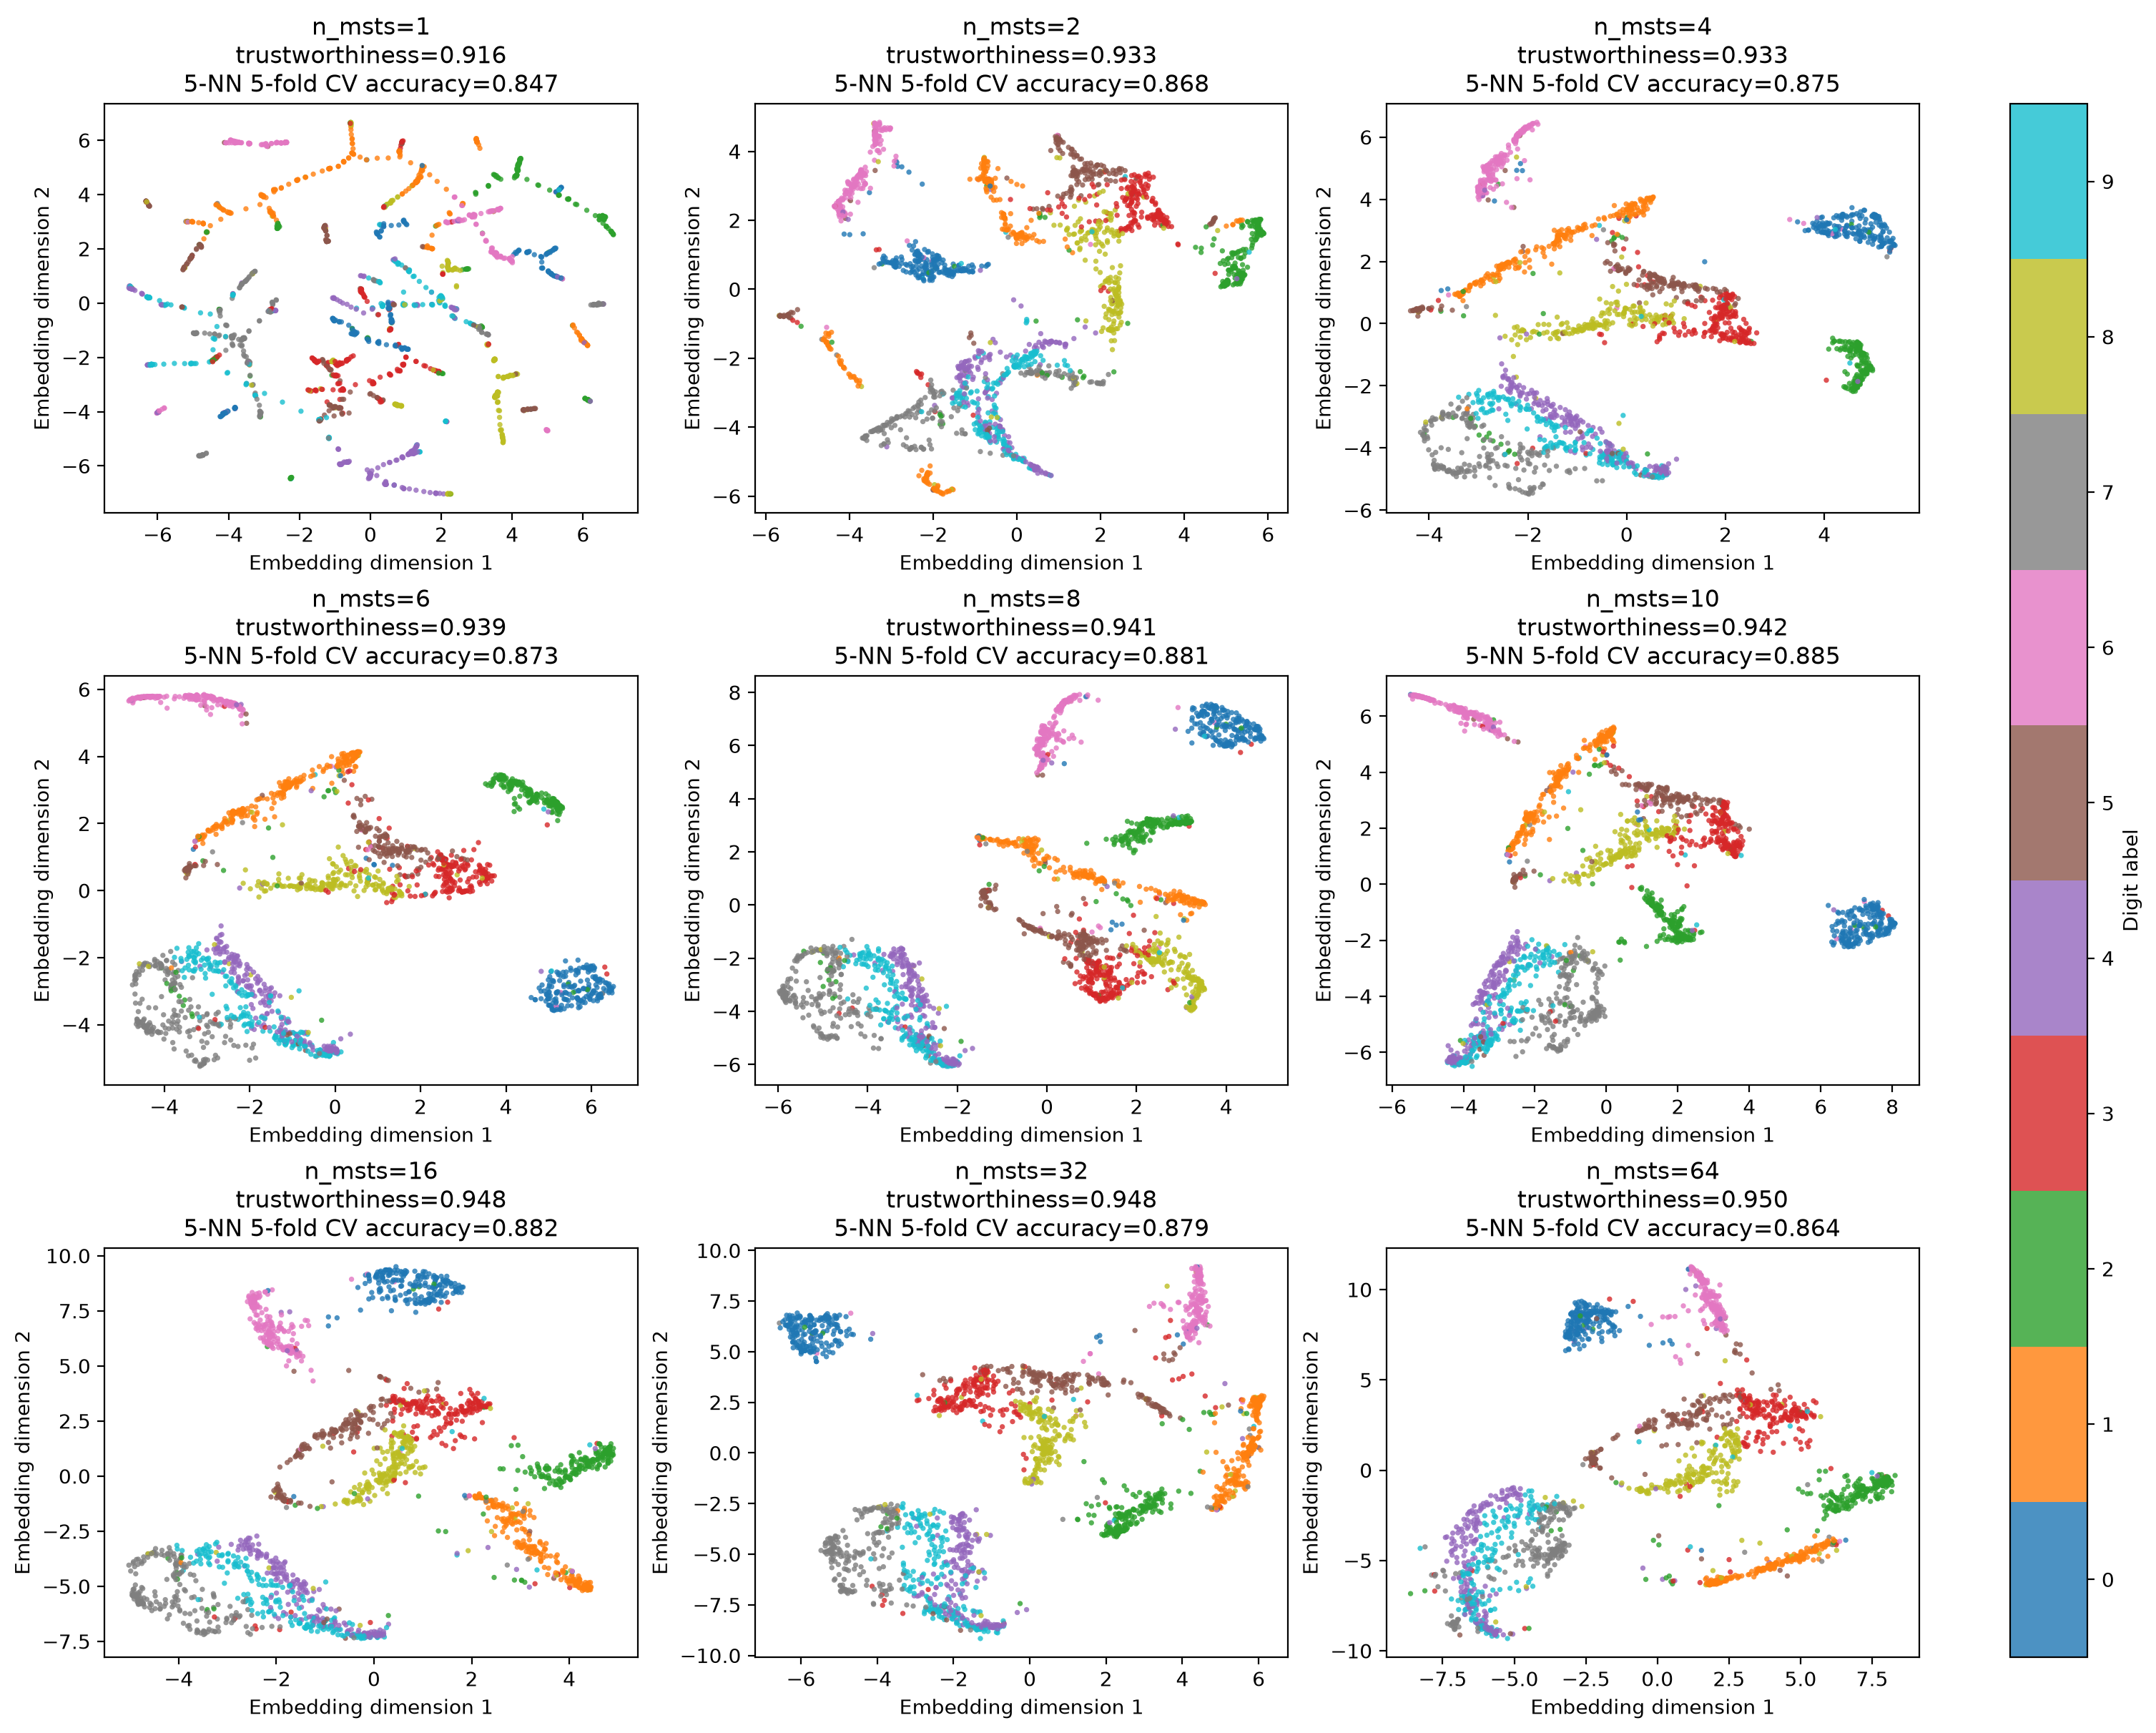

,n_msts,trustworthiness,5-NN 5-fold CV accuracy,seconds,elapsed,device
0,1,0.915967,0.8465,1.863361,2 sec,cpu
1,2,0.932661,0.8680,2.043585,2 sec,cpu
2,4,0.933291,0.8750,2.519644,3 sec,cpu
3,6,0.939174,0.8730,2.994177,3 sec,cpu
4,8,0.940915,0.8815,2.621833,3 sec,cpu
5,10,0.942414,0.8850,3.127379,3 sec,cpu
6,16,0.947835,0.8820,4.407047,4 sec,cpu
7,32,0.947953,0.8790,7.938283,8 sec,cpu
8,64,0.950473,0.8645,14.129309,14 sec,cpu


In [4]:
results, summary = run_sweep(
    X, labels, PARAMETER, VALUES, BASE_PARAMS,
    n_neighbors=TRUSTWORTHINESS_NEIGHBORS, n_jobs=N_JOBS,
)
summary